## HW2 Jenn Kaphammer
# USE CODE ON CANVAS AND CHANGE PDF FIGURES

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Q1 c - cable propogation

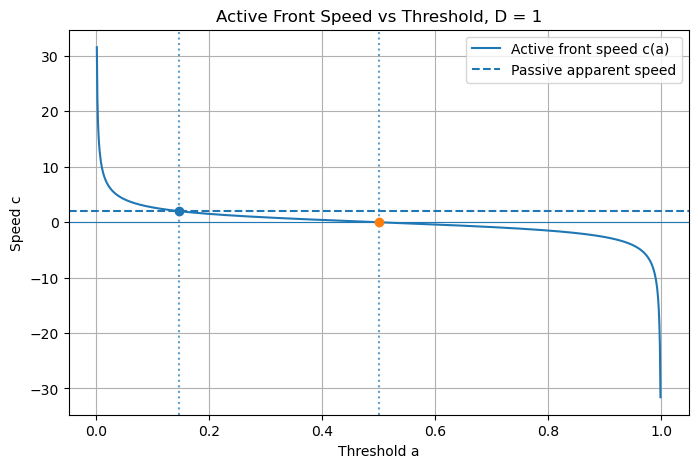

In [3]:
# D = 1 for this plot
D = 1
# not exactly a=0/1, denom goes to 0
a = np.linspace(0.001, 0.999, 1000)

# Active front speed
c = np.sqrt(D) * (1 - 2*a) / np.sqrt(a * (1 - a))

# Passive apparent speed  (part a)
c_passive = 2 * np.sqrt(D)
# Crossing point where active speed = passive speed
a_cross = (2 - np.sqrt(2)) / 4
# Stall point where c = 0
a_stall = 0.5

plt.figure(figsize=(8, 5))

plt.plot(a, c, label='Active front speed c(a)')
plt.axhline(c_passive, linestyle='--', label='Passive apparent speed')
plt.axhline(0, linewidth=0.8)

plt.scatter(a_cross, c_passive, zorder=3)
plt.scatter(a_stall, 0, zorder=3)

plt.axvline(a_cross, linestyle=':', alpha=0.7)
plt.axvline(a_stall, linestyle=':', alpha=0.7)

plt.xlabel('Threshold a')
plt.ylabel('Speed c')
plt.title('Active Front Speed vs Threshold, D = 1')

plt.legend()
plt.grid(True)

plt.show()

# Q2c - NMDA receptor blocked by Magnesium

In [4]:
# params
V0 = 16.13
EN = 0.0
gbar = 1.0 #scaling for plot

def B(V, Mg):
    return 1 / (1 + (Mg / 3.57) * np.exp(-V / V0))

def IN(V, Mg):
    return gbar * B(V, Mg) * (V - EN)

# voltage slope 0
Mg = 1.0

def slope_condition(V):
    return 1 + ((V - EN) * (1 - B(V, Mg))) / V0
#solve with numerical root method (brentq)
V_root = brentq(slope_condition, -90, 0)

print(f"Voltage where dI_N/dV = 0: {V_root:.3f} mV")

Voltage where dI_N/dV = 0: -26.957 mV


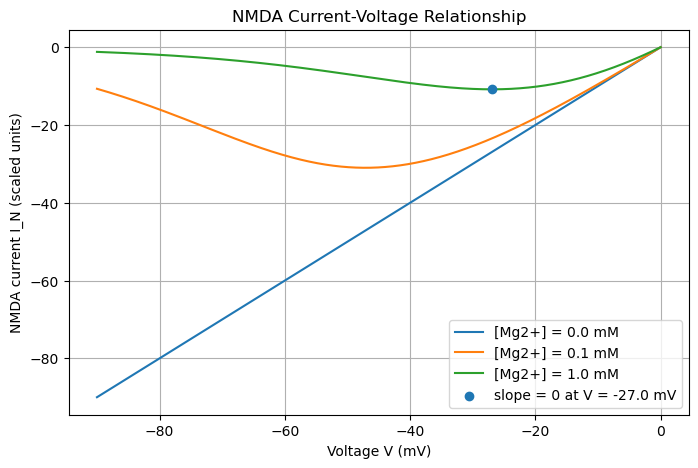

In [5]:
# Plot I_N(V) for Mg = 0, 0.1, 1 mM
V = np.linspace(-90, 0, 1000)

Mg_values = [0.0, 0.1, 1.0]

plt.figure(figsize=(8, 5))

for Mg in Mg_values:
    plt.plot(V, IN(V, Mg), label=f"[Mg2+] = {Mg} mM")

# mark slope-zero point for Mg = 1 mM
plt.scatter(V_root, IN(V_root, 1.0), zorder=3, label=f"slope = 0 at V = {V_root:.1f} mV")

plt.xlabel("Voltage V (mV)")
plt.ylabel("NMDA current I_N (scaled units)")
plt.title("NMDA Current-Voltage Relationship")
plt.legend()
plt.grid(True)

plt.show()

# Q4d - Voltage of Poisson events
#### partially based off of poisson_infer.py from Canvas

In [7]:
rng = np.random.default_rng(0)
tau = 0.020 #converted to seconds
mean_target = 10 #mV

In [8]:
#simulate 
def sim_shotnoise(ntau, T=20.0, dt=0.0001):
    # rate and jump size
    nu = ntau/tau
    w = mean_target/ntau

    # Poisson event times generation
    event_times = []
    t = 0.0
    
    #up to argument time ms
    while t < T:
        t += rng.exponential(1 / nu)
        if t < T:
            event_times.append(t)

    event_times = np.array(event_times)

    # record voltage
    times = np.arange(0, T, dt)
    V = np.zeros(len(times))

    voltage = 0.0
    last_time = 0.0
    event_index = 0

    for i, t_now in enumerate(times):

        # all events that happened before the sample time
        while (event_index < len(event_times) and event_times[event_index] <= t_now):
            t_event = event_times[event_index]
            # voltage decays until event occurs
            voltage *= np.exp(-(t_event - last_time) / tau)
            # event causes instantaneous jump of size w
            voltage += w
            last_time = t_event
            event_index += 1

        # decay from most recent event to current sample time
        voltage *= np.exp(-(t_now - last_time) / tau)
        last_time = t_now
        V[i] = voltage

    return times, V, nu, w

In [18]:
# loop through given homework values
ntau_val = [2, 20, 200]
results = []
simulations = {}

for ntau in ntau_val:
    # run simulation
    times, V, nu, w = sim_shotnoise(ntau)
    # save simulation for later plotting
    simulations[ntau] = {
        "times": times,
        "V": V,
        "nu": nu,
        "w": w
    }
    # get mean and var from sim
    mean_V = np.mean(V)
    var_V = np.var(V)
    centered = V - mean_V
    skew_V = np.mean(centered**3) / (np.std(V)**3)

    # theoretical mean/var/skew from hw
    mean_theory = nu * w * tau
    var_theory = nu * w**2 * tau / 2
    skew_theory = (2 * np.sqrt(2)) / (3 * np.sqrt(nu * tau))

    results.append({
        "nu*tau": ntau,
        "nu (Hz)": nu,
        "w (mV)": w,
        "Mean (sim)": mean_V,
        "Mean (theory)": mean_theory,
        "Variance (sim)": var_V,
        "Variance (theory)": var_theory,
        "Skewness (sim)": skew_V,
        "Skewness (theory)": skew_theory
    })

df = pd.DataFrame(results)

df

,nu*tau,nu (Hz),w (mV),Mean (sim),Mean (theory),Variance (sim),Variance (theory),Skewness (sim),Skewness (theory)
0,2,100.0,5.00,10.125958,10.0,25.114835,25.00,0.783933,0.666667
1,20,1000.0,0.50,9.978045,10.0,2.547449,2.50,0.097025,0.210819
2,200,10000.0,0.05,9.955621,10.0,0.279023,0.25,-2.636388,0.066667


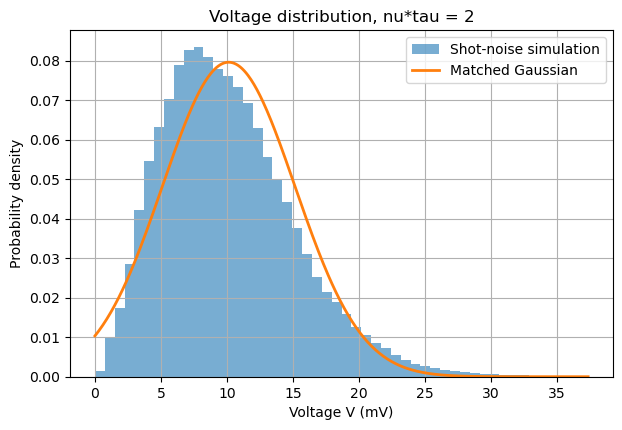

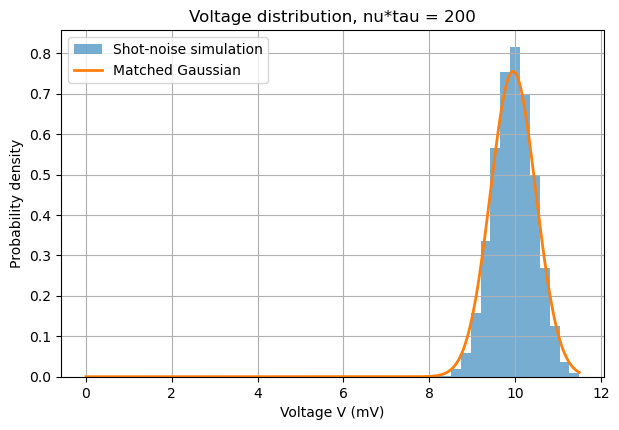

In [19]:
# plot only extreme cases
for ntau in [2, 200]:
    V = simulations[ntau]["V"]

    mean_V = np.mean(V)
    std_V = np.std(V)

    # x-values for matched Gaussian
    x = np.linspace(V.min(), V.max(), 500)

    # Gaussian with same mean and standard deviation as simulation
    gaussian = (
        1 / (std_V * np.sqrt(2 * np.pi))
        * np.exp(-(x - mean_V)**2 / (2 * std_V**2))
    )

    plt.figure(figsize=(7, 4.5))

    plt.hist(
        V,
        bins=50,
        density=True,
        alpha=0.6,
        label="Shot-noise simulation"
    )

    plt.plot(
        x,
        gaussian,
        linewidth=2,
        label="Matched Gaussian"
    )

    plt.xlabel("Voltage V (mV)")
    plt.ylabel("Probability density")
    plt.title(f"Voltage distribution, nu*tau = {ntau}")
    plt.legend()
    plt.grid(True)

    plt.show()

# Q5c - Noise IF
#### partially based on noise_if.py from Canvas

In [20]:
def sim_noisy_integrator(
    sigma2,
    mu=1.0,
    theta=1.0,
    T=1000.0,
    dt=0.001,
    burn_in=10.0,
    seed=0
):

    rng = np.random.default_rng(seed)
    times = np.arange(0, T, dt)
    V = np.zeros(len(times))
    u = 0.0
    spike_times = []

    for i, t in enumerate(times):
        # Euler-Maruyama update for 5c
        u += mu * dt + np.sqrt(2 * sigma2 * dt) * rng.standard_normal()
        # threshold crossing -> spike and reset
        if u >= theta:
            spike_times.append(t)
            u = 0.0
        V[i] = u

    spike_times = np.array(spike_times)

    # discard initial transient
    keep = times >= burn_in
    times_ss = times[keep]
    V_ss = V[keep]
    # only count spikes after burn-in
    spike_times_ss = spike_times[spike_times >= burn_in]

    return times_ss, V_ss, spike_times_ss

In [21]:
#5a theoretical stationary density
def p_theory(u, sigma2, mu=1.0, theta=1.0):
    nu = mu / theta
    p = np.zeros_like(u)
    
    # u < 0 branch
    below = u < 0
    p[below] = (nu / mu * (1 - np.exp(-mu * theta / sigma2))* np.exp(mu * u[below] / sigma2))

    # 0 <= u <= theta branch
    above = (u >= 0) & (u <= theta)
    p[above] = (nu / mu* (1 - np.exp(mu * (u[above] - theta) / sigma2)))
    
    return p

In [22]:
#provided 5c vals
sigma2_vals = [0.25, 1.0, 4.0]

results = []
simulations = {}

for sigma2 in sigma2_vals:

    times, V, spike_times = sim_noisy_integrator(sigma2=sigma2)
    # save for later plotting
    simulations[sigma2] = {
        "times": times,
        "V": V,
        "spike_times": spike_times
    }
    # measured firing rate
    duration = times[-1] - times[0]
    firing_rate_sim = len(spike_times) / duration

    # theoretical firing rate
    firing_rate_theory = 1.0   # mu/theta = 1/1
    # measured fraction below reset
    frac_below_sim = np.mean(V < 0)
    # theoretical fraction below reset
    frac_below_theory = (sigma2 * (1 - np.exp(-1 / sigma2)))

    results.append({
        "sigma^2": sigma2,
        "Rate (sim)": firing_rate_sim,
        "Rate (theory)": firing_rate_theory,
        "Frac below 0 (sim)": frac_below_sim,
        "Frac below 0 (theory)": frac_below_theory
    })


df = pd.DataFrame(results)

df

,sigma^2,Rate (sim),Rate (theory),Frac below 0 (sim),Frac below 0 (theory)
0,0.25,1.007072,1.0,0.219448,0.245421
1,1.00,1.014142,1.0,0.610742,0.632121
2,4.00,1.031314,1.0,0.871355,0.884797


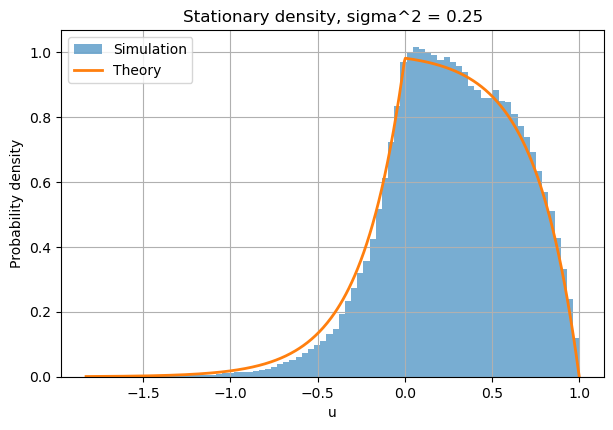

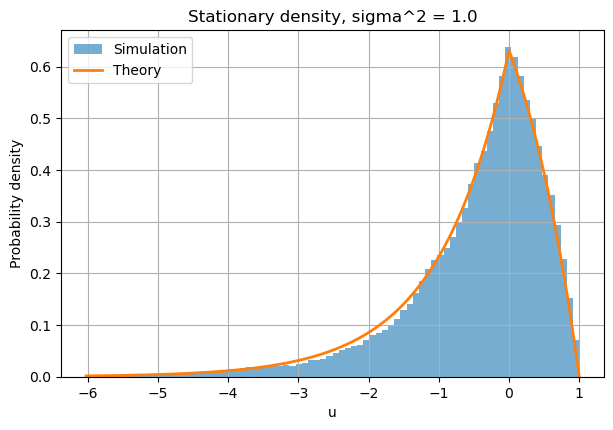

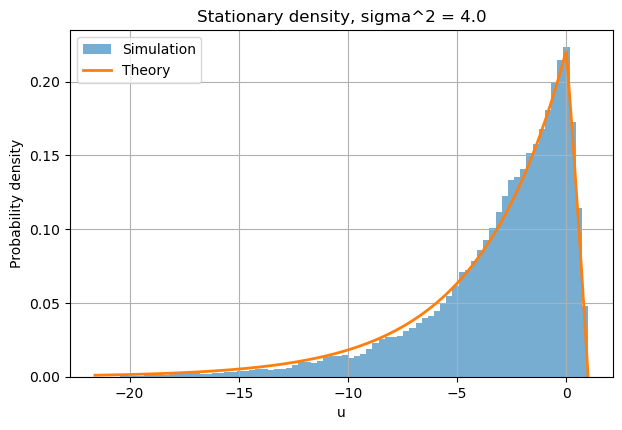

In [23]:
#histogram
for sigma2 in sigma2_vals:

    V = simulations[sigma2]["V"]

    # x-range for theoretical density
    u_vals = np.linspace(
        V.min(),
        1.0,
        500
    )

    p_vals = p_theory(
        u_vals,
        sigma2=sigma2
    )

    plt.figure(figsize=(7, 4.5))

    plt.hist(
        V,
        bins=80,
        density=True,
        alpha=0.6,
        label="Simulation"
    )

    plt.plot(
        u_vals,
        p_vals,
        linewidth=2,
        label="Theory"
    )

    plt.xlabel("u")
    plt.ylabel("Probability density")
    plt.title(f"Stationary density, sigma^2 = {sigma2}")
    plt.legend()
    plt.grid(True)

    plt.show()